In [50]:
import pandas as pd
import numpy as np

In [76]:
df=pd.read_csv('./datasets/adult.csv')

In [77]:
df.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [79]:
df.drop(['fnlwgt'],axis=1,inplace=True)

In [80]:
df.isnull().sum()

age               0
workclass         0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [81]:
income_counts=df['income'].value_counts()

In [82]:
import matplotlib.pyplot as plt

<Axes: xlabel='income'>

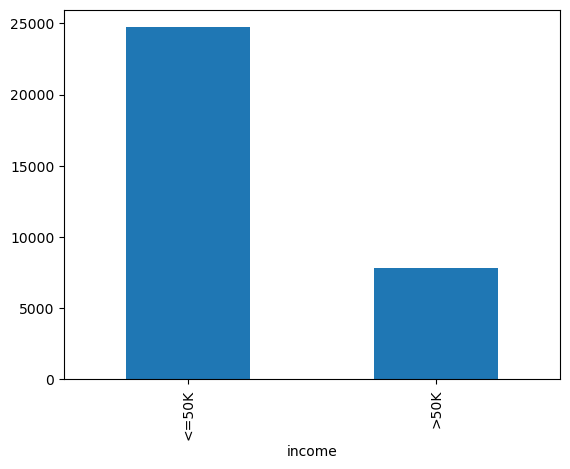

In [83]:
income_counts.plot(kind='bar')

In [84]:
df=pd.get_dummies(df, columns=['workclass', 'education', 'marital.status', 'occupation', 
    'relationship', 'race', 'sex', 'native.country'])

In [85]:
df.describe()

,age,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,10.080679,1077.648844,87.303830,40.437456
std,13.640433,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Columns: 108 entries, age to native.country_Yugoslavia
dtypes: bool(102), int64(5), object(1)
memory usage: 4.7+ MB


In [87]:
df.columns

Index(['age', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week', 'income', 'workclass_?', 'workclass_Federal-gov',
       'workclass_Local-gov', 'workclass_Never-worked',
       ...
       'native.country_Portugal', 'native.country_Puerto-Rico',
       'native.country_Scotland', 'native.country_South',
       'native.country_Taiwan', 'native.country_Thailand',
       'native.country_Trinadad&Tobago', 'native.country_United-States',
       'native.country_Vietnam', 'native.country_Yugoslavia'],
      dtype='object', length=108)

In [88]:
from sklearn.preprocessing import MinMaxScaler

In [89]:
scaler=MinMaxScaler()

In [90]:
df[['age','education.num','capital.gain','capital.loss','hours.per.week']]=scaler.fit_transform(df[['age','education.num','capital.gain','capital.loss','hours.per.week']])

In [91]:
df.head()

,age,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,1.000000,0.533333,0.0,1.000000,0.397959,<=50K,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.890411,0.533333,0.0,1.000000,0.173469,<=50K,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.671233,0.600000,0.0,1.000000,0.397959,<=50K,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0.506849,0.200000,0.0,0.895317,0.397959,<=50K,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0.328767,0.600000,0.0,0.895317,0.397959,<=50K,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [92]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [93]:
x = df.drop(columns=['income'])
y = df['income'].apply(lambda x: 1 if x == ">50K" else 0)

In [94]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [95]:
model = RandomForestClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [96]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      7420
           1       0.71      0.64      0.67      2349

    accuracy                           0.85      9769
   macro avg       0.80      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769

